## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

- **Percepción (S):** ingreso_mensual del solicitante, monto_solicitado, y si tiene_historial_moroso (True/False).
- **Acciones (A):** aprobar la solicitud, aprobar con condiciones (tasa más alta o monto reducido), o rechazar la solicitud.
- **Entorno (E):** el sistema de evaluación crediticia del banco, recibiendo solicitudes de distintos clientes.
- **Objetivo:** aprobar créditos que el cliente pueda pagar, minimizando el riesgo de impago para el banco.
- **Medida de desempeño (P):** proporción de créditos aprobados que terminan siendo pagados correctamente, frente a la proporción de impagos.

### Justificación de las reglas

Las reglas se basan en la relación entre el monto solicitado y el ingreso mensual, porque mientras mayor sea esa relación, más comprometido queda el ingreso del cliente para pagar la deuda, y por lo tanto mayor es el riesgo de impago. El historial moroso se usa como un agravante: un cliente con historial moroso necesita una relación monto/ingreso más baja para ser aprobado sin condiciones, porque ya demostró antes dificultad para pagar. Combinar ambas variables (en vez de solo una) evita dos errores: rechazar automáticamente a alguien con mal historial pero que pide un monto bajo y manejable, o aprobar sin condiciones a alguien que pide un monto muy alto solo porque nunca fue moroso antes.

### Código

In [10]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    # Relacion entre lo pedido y lo que gana el cliente: a mayor relacion, mayor riesgo de impago
    relacion = monto_solicitado / ingreso_mensual
    
    # Caso de mayor riesgo: relacion muy alta, o relacion moderada combinada con mal historial
    if relacion > 0.5 or (tiene_historial_moroso and relacion > 0.3):
        return "rechazar", f"relacion monto/ingreso de {relacion:.2f} representa demasiado riesgo" + (" con historial moroso" if tiene_historial_moroso else "")
    # Caso de riesgo moderado: se aprueba pero con condiciones (tasa mas alta, monto reducido, etc.)
    elif relacion > 0.3 or tiene_historial_moroso:
        return "aprobar con condiciones", f"relacion monto/ingreso de {relacion:.2f}" + (" con historial moroso" if tiene_historial_moroso else " moderada")
    # Caso de bajo riesgo: se aprueba sin condiciones
    else:
        return "aprobar", f"relacion monto/ingreso de {relacion:.2f} es baja y sin historial moroso"

### Simulación y pruebas

In [8]:
casos = [
    (5000, 1000, False),   # relacion 0.2, sin mora -> aprobar
    (5000, 2500, False),   # relacion 0.5 exacta, sin mora -> caso limite
    (5000, 2000, True),    # relacion 0.4, con mora -> rechazar
    (3000, 2000, False),   # relacion 0.67, sin mora -> rechazar (monto muy alto)
    (4000, 1500, True),    # relacion 0.375, con mora -> rechazar
    (6000, 1200, True),    # relacion 0.2, con mora -> aprobar con condiciones
]

for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Ingreso: {ingreso}, Monto: {monto}, Moroso: {moroso} -> {accion} ({motivo})")

Ingreso: 5000, Monto: 1000, Moroso: False -> aprobar (relacion monto/ingreso de 0.20 es baja y sin historial moroso)
Ingreso: 5000, Monto: 2500, Moroso: False -> aprobar con condiciones (relacion monto/ingreso de 0.50 moderada)
Ingreso: 5000, Monto: 2000, Moroso: True -> rechazar (relacion monto/ingreso de 0.40 representa demasiado riesgo con historial moroso)
Ingreso: 3000, Monto: 2000, Moroso: False -> rechazar (relacion monto/ingreso de 0.67 representa demasiado riesgo)
Ingreso: 4000, Monto: 1500, Moroso: True -> rechazar (relacion monto/ingreso de 0.38 representa demasiado riesgo con historial moroso)
Ingreso: 6000, Monto: 1200, Moroso: True -> aprobar con condiciones (relacion monto/ingreso de 0.20 con historial moroso)


### Visualización

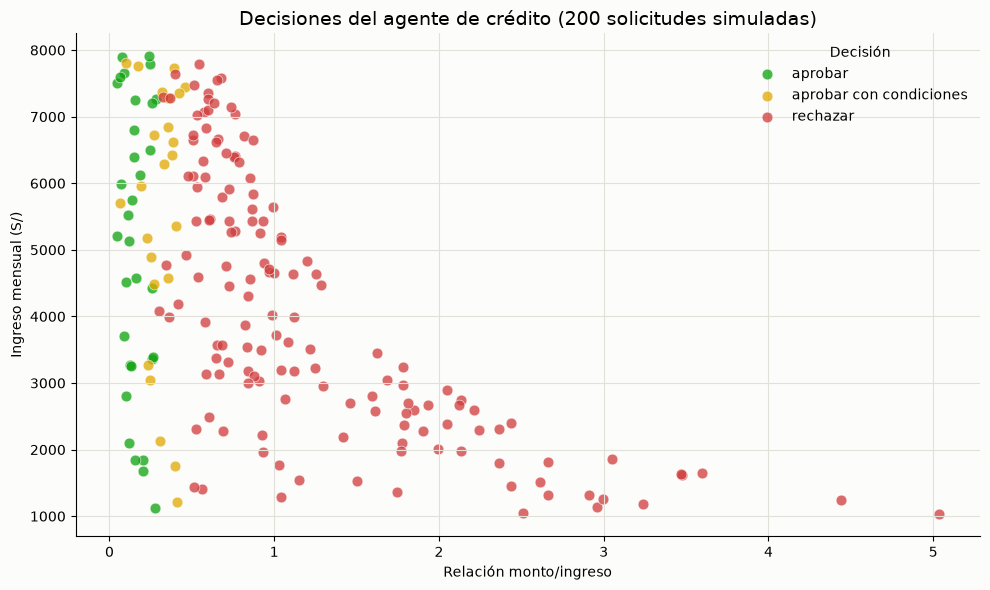

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

ingresos = np.random.uniform(1000, 8000, n)
montos = np.random.uniform(200, 6000, n)
morosos = np.random.rand(n) < 0.3  # 30% de solicitantes con historial moroso

relaciones = montos / ingresos
acciones = []
for i in range(n):
    accion, _ = agente_credito(ingresos[i], montos[i], morosos[i])
    acciones.append(accion)

colores = {"aprobar": "#0ca30c", "aprobar con condiciones": "#e0a800", "rechazar": "#d03b3b"}

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for accion_tipo in colores:
    mask = [a == accion_tipo for a in acciones]
    ax.scatter(
        relaciones[mask], ingresos[mask],
        s=60, alpha=0.75,
        c=colores[accion_tipo],
        edgecolors="white", linewidths=0.5,
        label=accion_tipo,
    )

ax.set_title("Decisiones del agente de crédito (200 solicitudes simuladas)", fontsize=14)
ax.set_xlabel("Relación monto/ingreso")
ax.set_ylabel("Ingreso mensual (S/)")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Decisión", frameon=False, loc="upper right")
plt.tight_layout()
plt.show()